In [1]:
import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
from copy import deepcopy as copy
import importlib
import phise

In [2]:
importlib.reload(phise)

ctx = phise.examples.contexts.get_PHOB()
ctx.interferometer.fov = 0.1 * u.deg
ctx.chip.calibrate()
ctx.Γ = 20 * u.nm # 1nm of upstream piston rms
ctx_h0 = copy(ctx)
ctx_h0.target.companions = []
ctx_h1 = copy(ctx)
ctx_h1.target.companions = [phise.Companion(1e-2, 0.02*u.deg, 0*u.deg)]

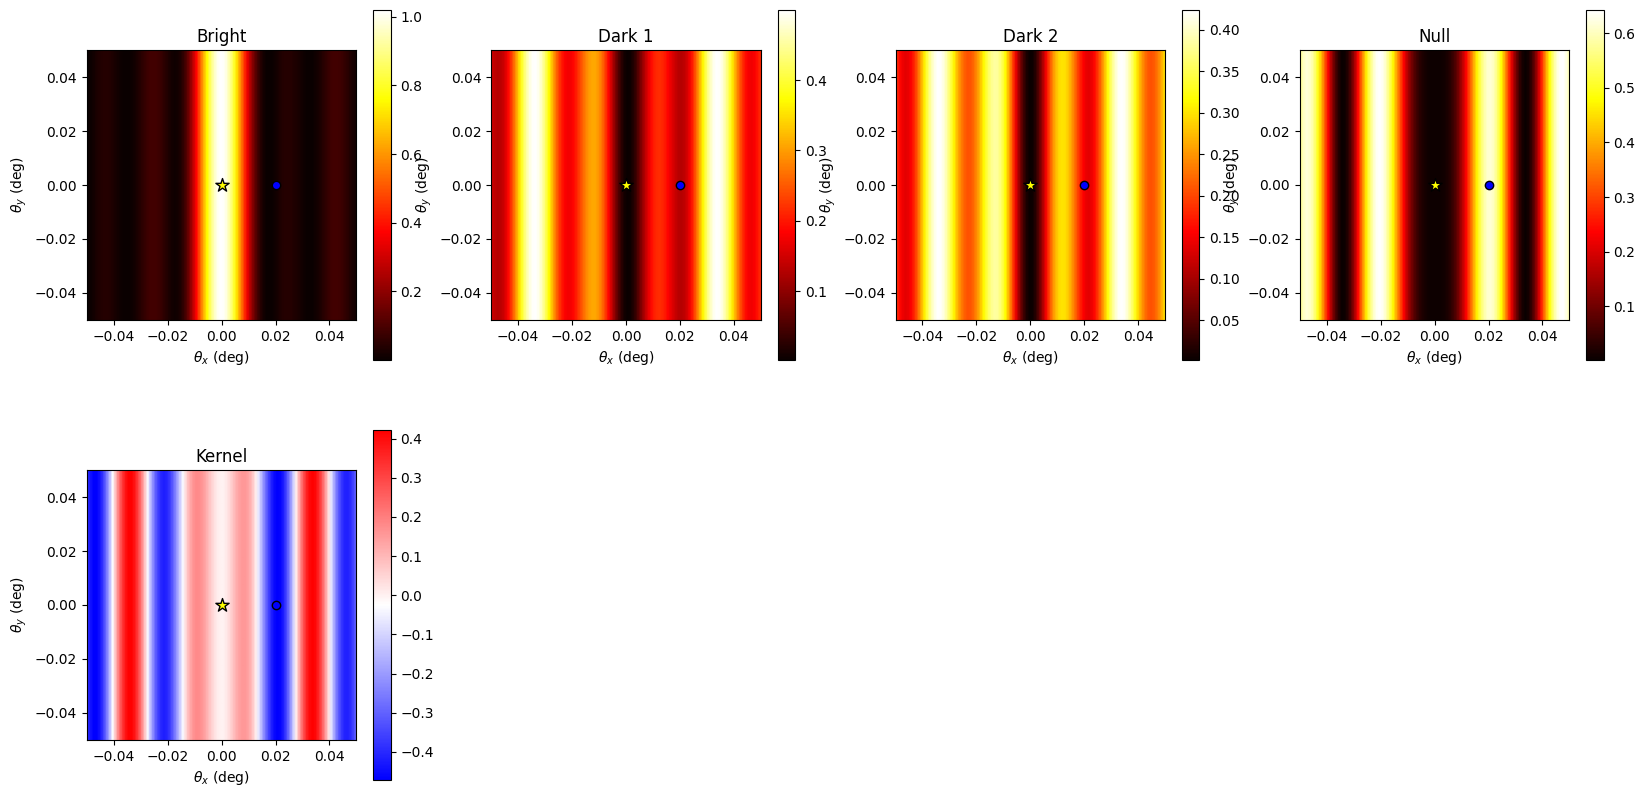


Tunable Laser Star throughputs:
----------
   Bright: 101.93%,   Dark 1: 0.40%,   Dark 2: 0.18%,   Null: 0.50%
   Kernel: -0.32%
Unnamed Companion throughputs:
----------
   Bright: 1.30%,   Dark 1: 13.07%,   Dark 2: 14.99%,   Null: 61.35%
   Kernel: -46.36%
Target "Tunable Laser"
  f: 1e-05 W / (nm m2)
  δ: -90 deg
  Companions:
    Companion "Unnamed Companion"
      Contrast: 0.0001
      Angular separation: 0.02 deg
      Parallactic angle: 0 deg
---
Camera "Cred3"
  Exposure time: 0.0014 s
  QE: 73% | RON: 37 e- | DC: 7.6e+05 e-/s | Gain: 2 e-/ADU
  Resolution: 11 px | Spot size: 1.0 px | HDR: [] * exposure time



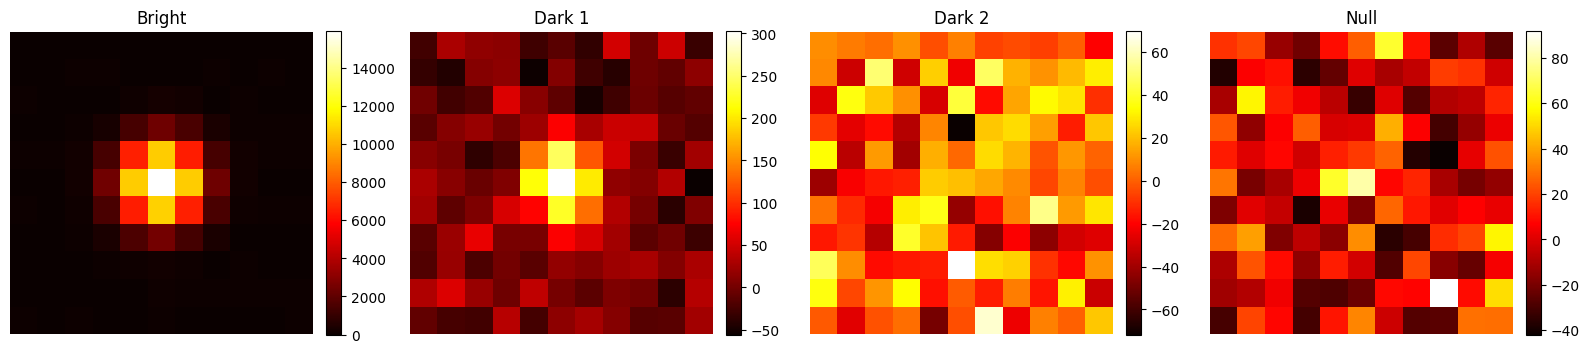

Camera "Cred3"
  Exposure time: 0.014 s
  QE: 73% | RON: 37 e- | DC: 7.6e+05 e-/s | Gain: 2 e-/ADU
  Resolution: 11 px | Spot size: 1.0 px | HDR: [] * exposure time



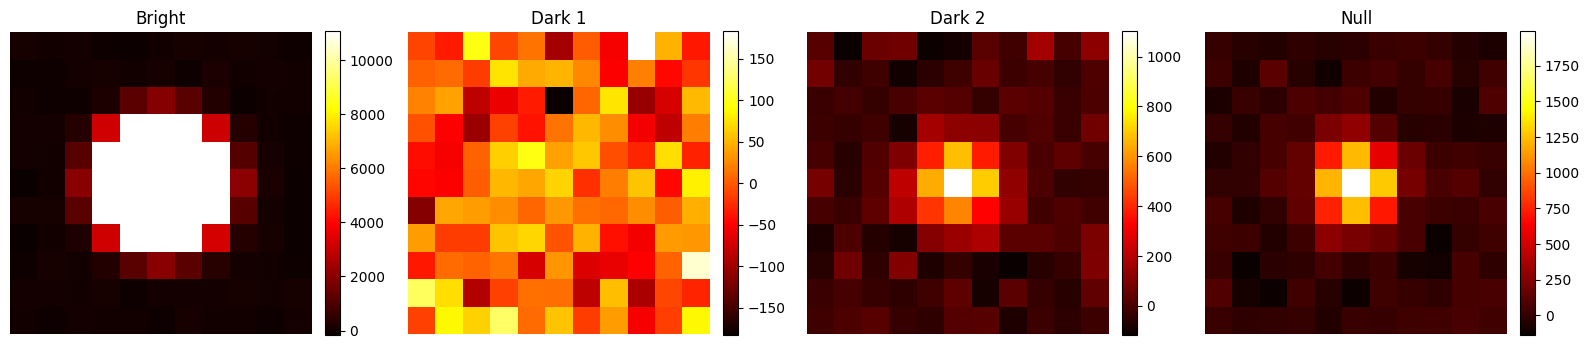

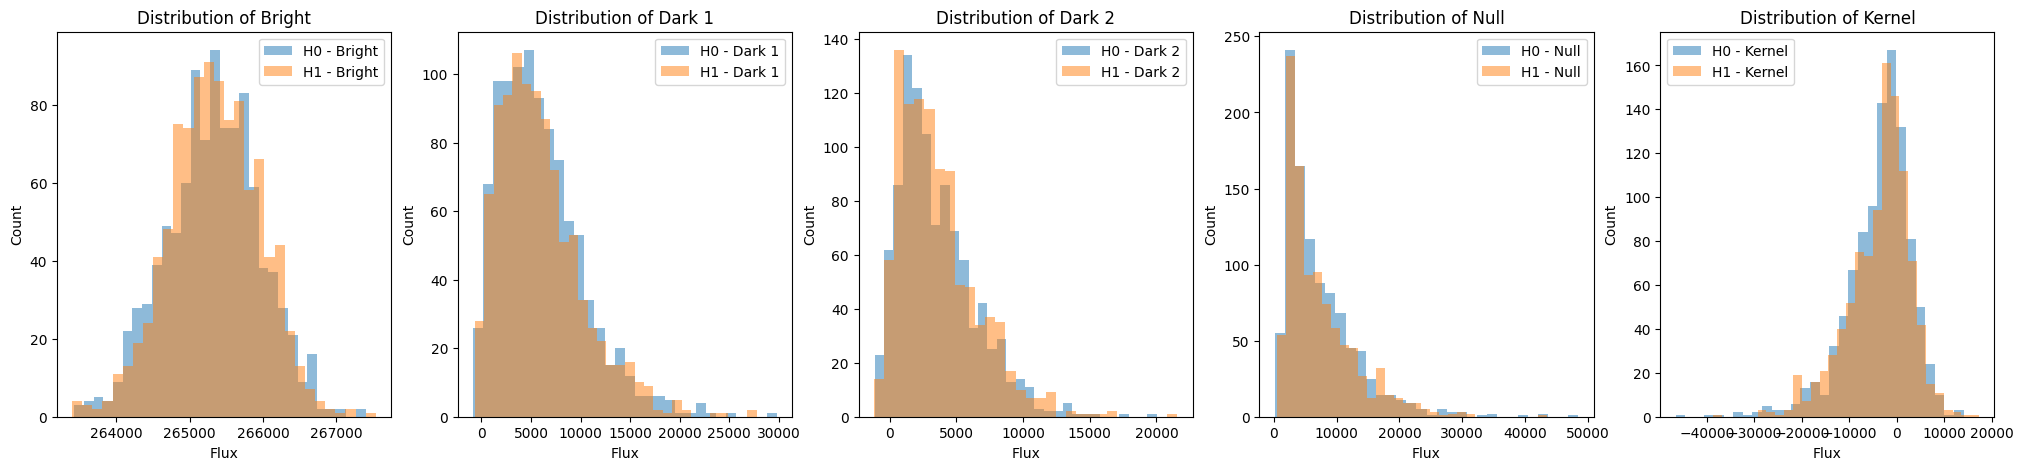

Power of Mean: 2.62%
Power of Median: 4.23%
Power of Kolmogorov-Smirnov: 3.2%
Power of Cramer von Mises: 3.48%
Power of Flattening: 1.71%
Power of Median of Abs: 4.23%


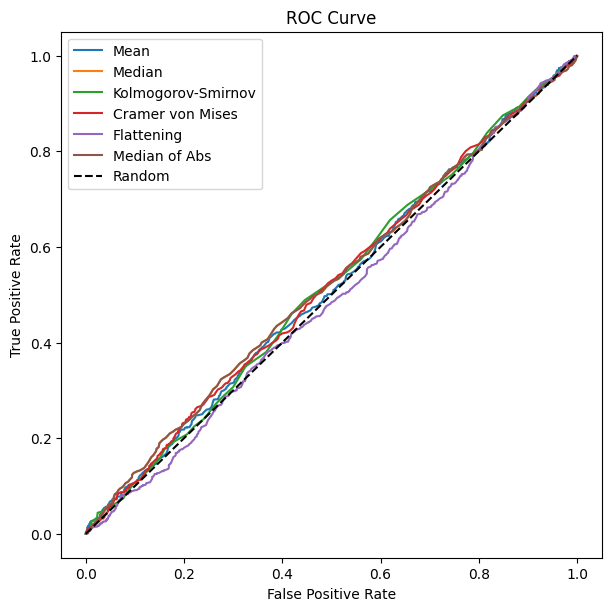

Power of Mean: 37.71%
Power of Median: 29.59%
Power of Kolmogorov-Smirnov: 3.37%
Power of Cramer von Mises: 3.72%
Power of Flattening: 3.56%
Power of Median of Abs: 29.59%


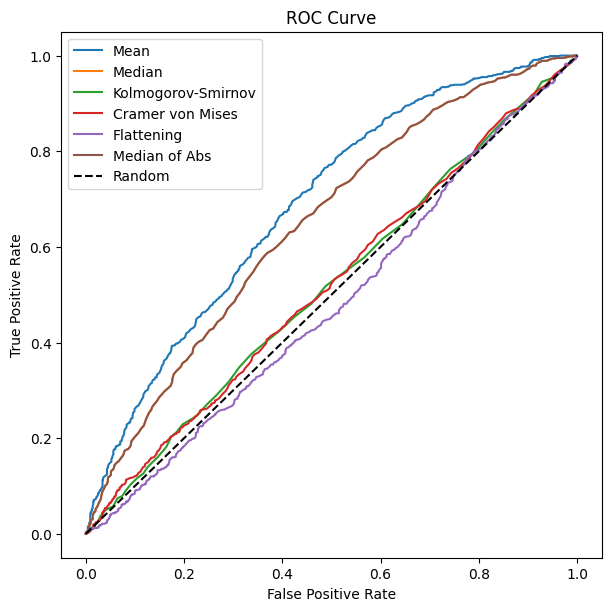

Power of Mean: 35.57%
Power of Median: 26.46%
Power of Kolmogorov-Smirnov: 5.57%
Power of Cramer von Mises: 6.72%
Power of Flattening: 3.69%
Power of Median of Abs: 26.46%


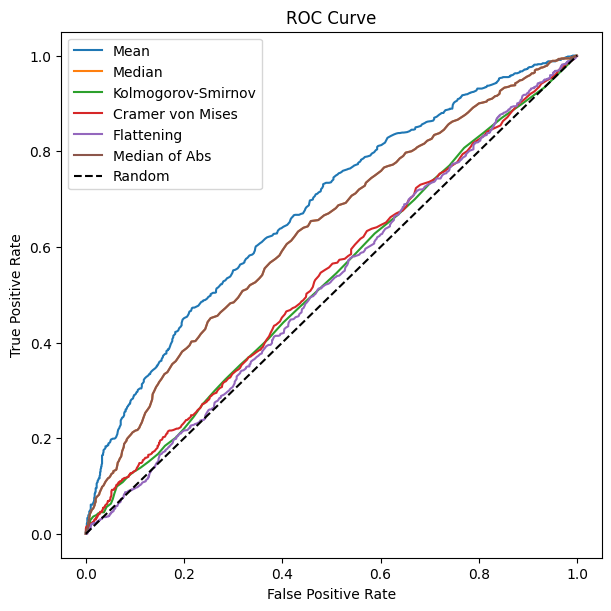

Power of Mean: 98.1%
Power of Median: 94.07%
Power of Kolmogorov-Smirnov: 72.51%
Power of Cramer von Mises: 76.46%
Power of Flattening: 0.61%
Power of Median of Abs: 94.07%


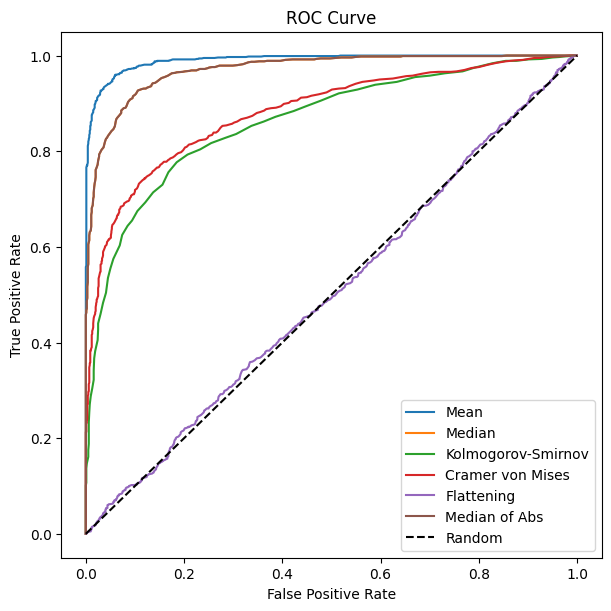

Power of Mean: 83.0%
Power of Median: 72.81%
Power of Kolmogorov-Smirnov: 37.74%
Power of Cramer von Mises: 40.08%
Power of Flattening: 1.64%
Power of Median of Abs: 48.77%


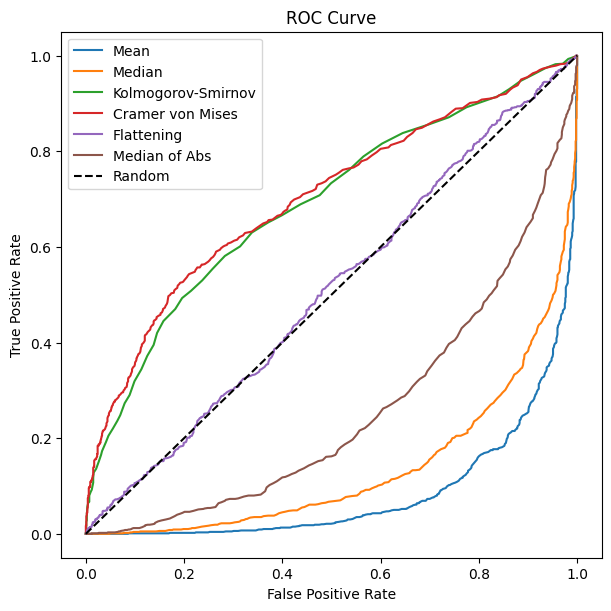

In [3]:
import os

roc_ctx_h1 = copy(ctx_h1)
roc_ctx_h1.target.companions[0].c = 1e-4
roc_ctx_h1.plot_transmission_maps(N=100)
print(roc_ctx_h1.target)
print("---")
roc_ctx_h1.camera.e = roc_ctx_h1.get_reference_exposure_time(target_adu_fraction=1)
print(roc_ctx_h1.camera)  
roc_ctx_h1.observe(mode="demo"); plt.show()
roc_ctx_h1.camera.e = roc_ctx_h1.get_reference_exposure_time(target_adu_fraction=10)
print(roc_ctx_h1.camera)  
roc_ctx_h1.observe(mode="demo"); plt.show()

chip = copy(roc_ctx_h1.chip)
camera = copy(roc_ctx_h1.camera)

roc_ctx_h0 = copy(roc_ctx_h1)
roc_ctx_h0.target.companions = []

roc_ctx_h1.name = "H1"
roc_ctx_h0.name = "H0"
roc_ctx_h1.plot_distributions(samples=1000, ctx_h0=roc_ctx_h0); plt.show()

force_generate = False
if os.path.exists("roc_data_phob.npz") and not force_generate:
    loaded = np.load("roc_data_phob.npz")
    T0 = loaded["T0"]
    T1 = loaded["T1"]
else:
    T0, T1 = phise.roc.generate_data(roc_ctx_h1, roc_ctx_h0, nmc=100, size=1000, progress_callback=lambda p: print(f"Progress: {p:.1%}", end='\r'), randomize_position=False)
    np.savez("roc_data_phob.npz", T0=T0, T1=T1)

for i in range(5):
    phise.roc.plot_roc_curves(T0[i], T1[i])

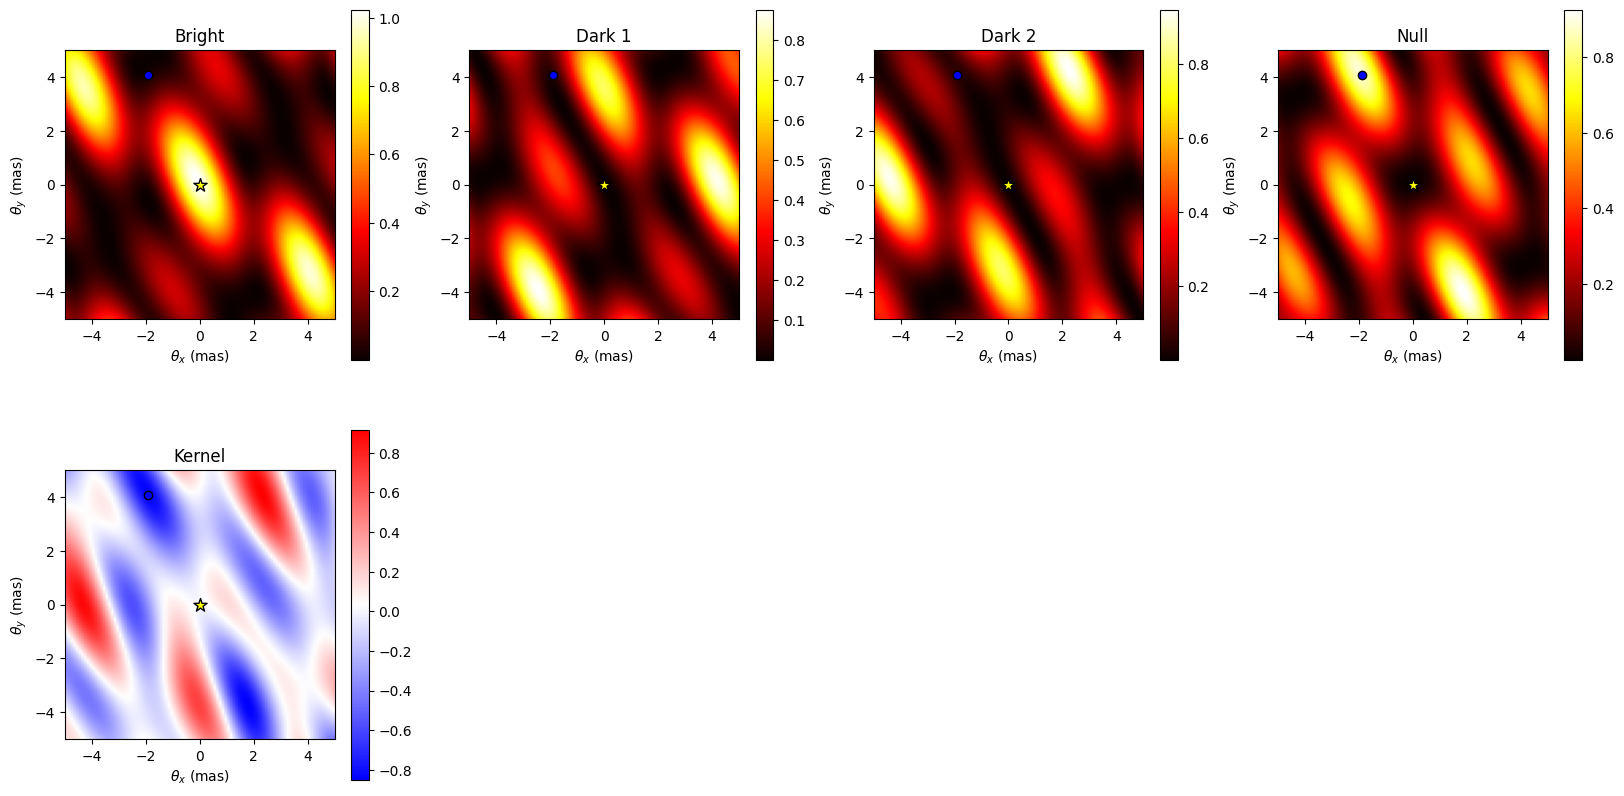


Sun-like @ 10pc Star throughputs:
----------
   Bright: 101.93%,   Dark 1: 0.40%,   Dark 2: 0.18%,   Null: 0.50%
   Kernel: -0.32%
Hypothetical Companion throughputs:
----------
   Bright: 2.53%,   Dark 1: 3.90%,   Dark 2: 4.31%,   Null: 87.76%
   Kernel: -83.44%
Target "Sun-like @ 10pc"
  f: 1e-12 W / (nm m2)
  δ: -65 deg
  Companions:
    Companion "Hypothetical Companion"
      Contrast: 0.002
      Angular separation: 4.5 mas
      Parallactic angle: 1.2e+02 deg
---
Camera "Cred3"
  Exposure time: 2.5e-05 s
  QE: 73% | RON: 37 e- | DC: 7.6e+05 e-/s | Gain: 2 e-/ADU
  Resolution: 11 px | Spot size: 1.0 px | HDR: [] * exposure time



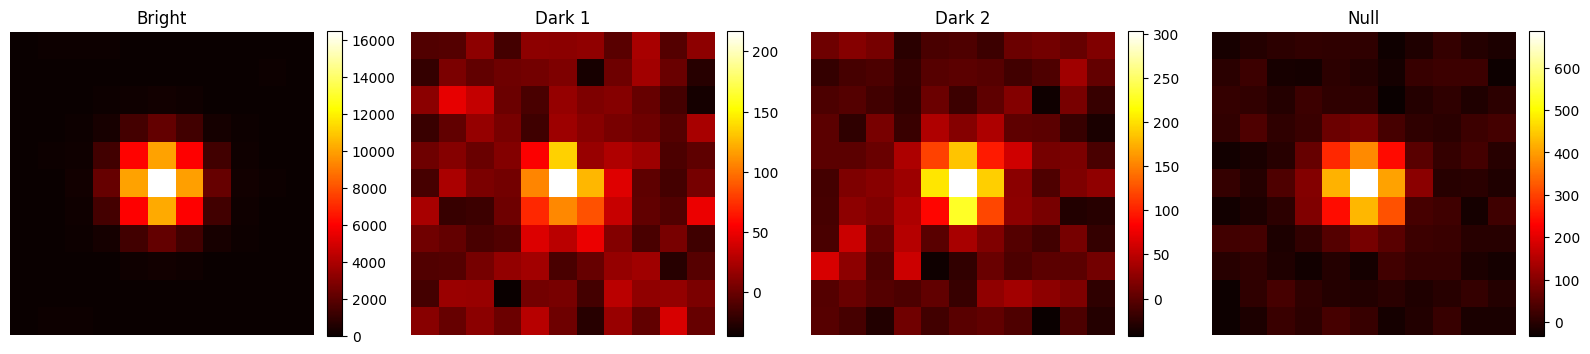

Camera "Cred3"
  Exposure time: 0.00025 s
  QE: 73% | RON: 37 e- | DC: 7.6e+05 e-/s | Gain: 2 e-/ADU
  Resolution: 11 px | Spot size: 1.0 px | HDR: [] * exposure time



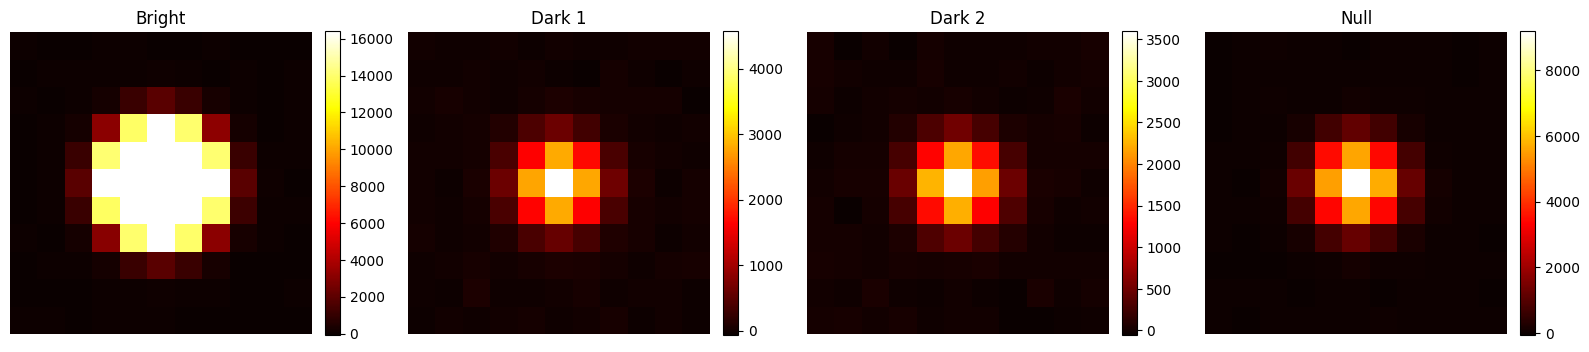

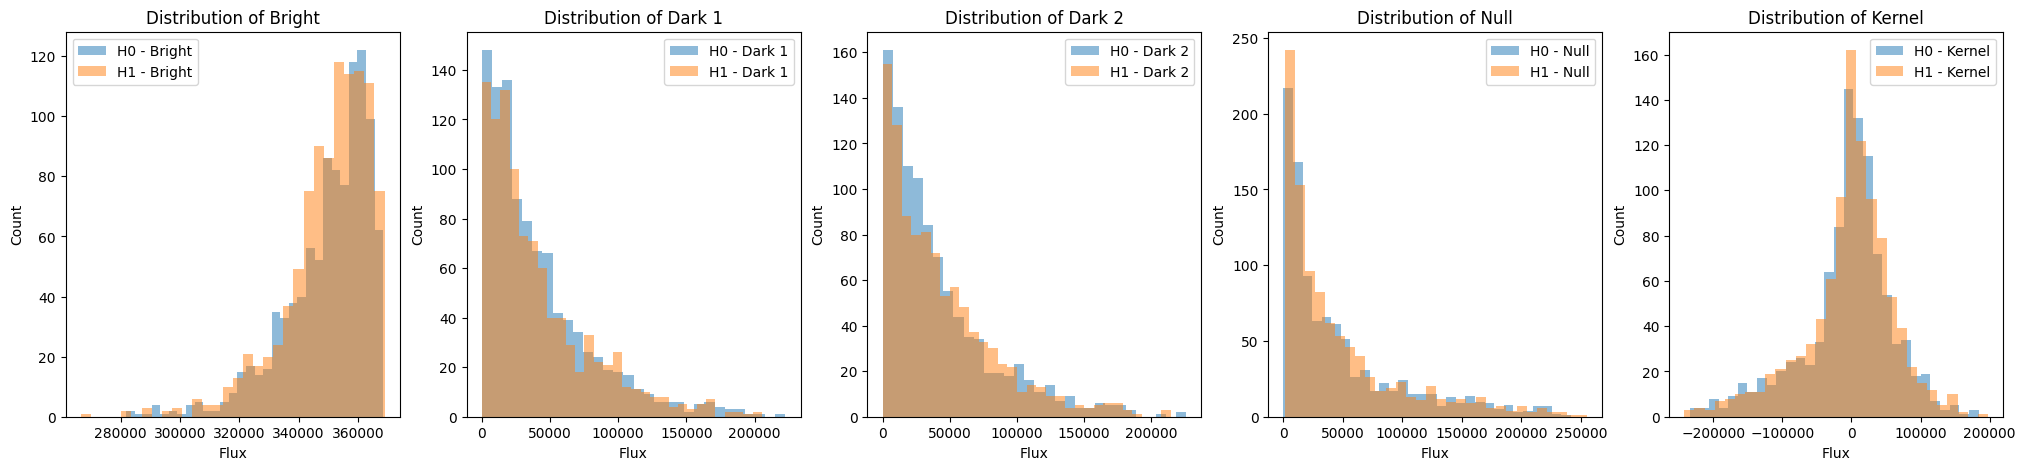

Power of Mean: 12.0%
Power of Median: 7.63%
Power of Kolmogorov-Smirnov: 4.18%
Power of Cramer von Mises: 2.46%
Power of Flattening: 13.2%
Power of Median of Abs: 7.63%


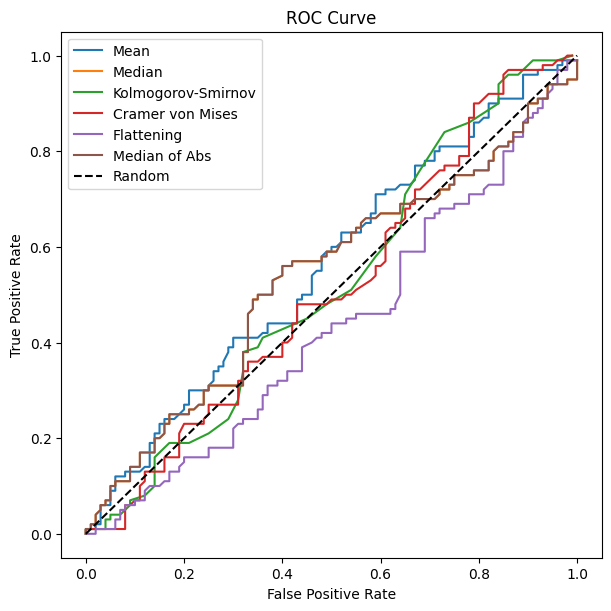

Power of Mean: 1.27%
Power of Median: 9.76%
Power of Kolmogorov-Smirnov: 2.92%
Power of Cramer von Mises: 5.81%
Power of Flattening: 4.21%
Power of Median of Abs: 9.76%


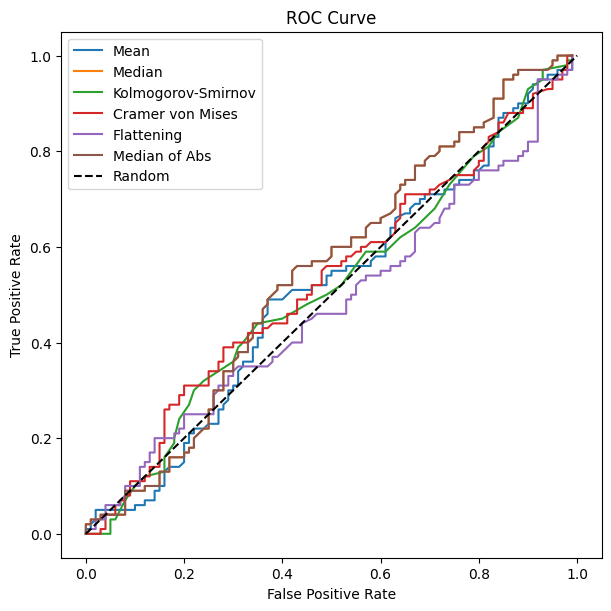

Power of Mean: 0.94%
Power of Median: 6.42%
Power of Kolmogorov-Smirnov: 2.69%
Power of Cramer von Mises: 2.7%
Power of Flattening: 5.0%
Power of Median of Abs: 6.42%


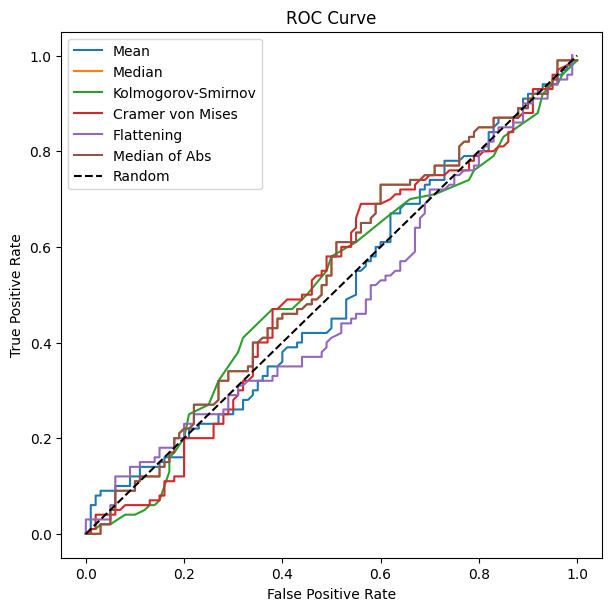

Power of Mean: 56.82%
Power of Median: 60.81%
Power of Kolmogorov-Smirnov: 98.83%
Power of Cramer von Mises: 96.5%
Power of Flattening: 9.13%
Power of Median of Abs: 60.81%


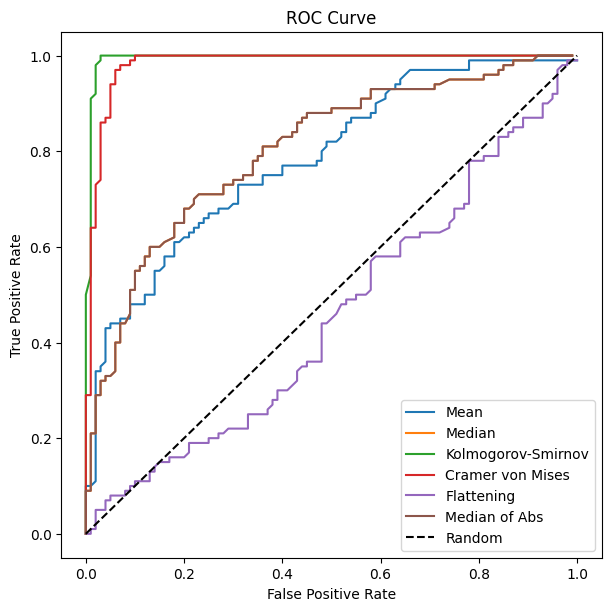

Power of Mean: 42.25%
Power of Median: 67.44%
Power of Kolmogorov-Smirnov: 19.18%
Power of Cramer von Mises: 17.44%
Power of Flattening: 2.62%
Power of Median of Abs: 16.84%


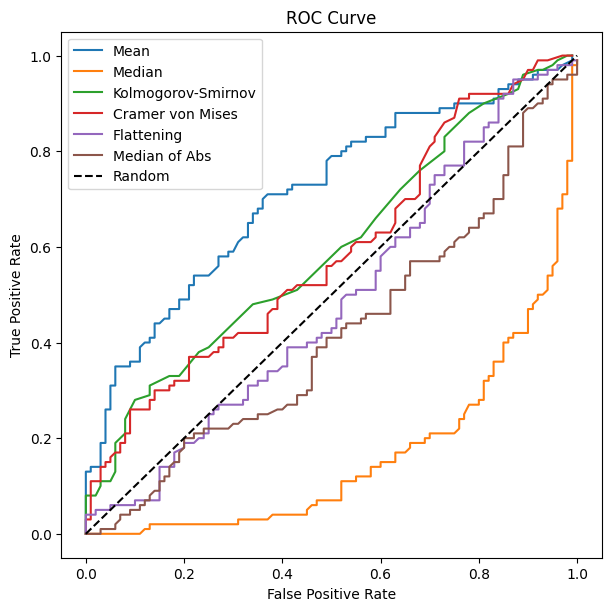

In [4]:
import os

roc_ctx_h1 = phise.examples.contexts.get_VLTI()
roc_ctx_h1.chip = copy(chip)
roc_ctx_h1.camera = copy(camera)
roc_ctx_h1.target.companions[0].c = 2e-3
roc_ctx_h1.target.companions[0].ρ = 4.5 * u.mas
roc_ctx_h1.target.companions[0].θ = 115 * u.deg
roc_ctx_h1.plot_transmission_maps(N=100)
print(roc_ctx_h1.target)
print("---")
roc_ctx_h1.camera.e = roc_ctx_h1.get_reference_exposure_time(target_adu_fraction=1)
print(roc_ctx_h1.camera)  
roc_ctx_h1.observe(mode="demo"); plt.show()
roc_ctx_h1.camera.e = roc_ctx_h1.get_reference_exposure_time(target_adu_fraction=10)
print(roc_ctx_h1.camera)  
roc_ctx_h1.observe(mode="demo"); plt.show()

# roc_ctx_h1.interferometer.Δλ = 100 * u.um

roc_ctx_h0 = copy(roc_ctx_h1)
roc_ctx_h0.target.companions = []

roc_ctx_h1.name = "H1"
roc_ctx_h0.name = "H0"
roc_ctx_h1.plot_distributions(samples=1000, ctx_h0=roc_ctx_h0); plt.show()

force_generate = False
if os.path.exists("roc_data_vlti.npz") and not force_generate:
    loaded = np.load("roc_data_vlti.npz")
    T0 = loaded["T0"]
    T1 = loaded["T1"]
else:
    T0, T1 = phise.roc.generate_data(roc_ctx_h1, roc_ctx_h0, nmc=100, size=1000, progress_callback=lambda p: print(f"Progress: {p:.1%}", end='\r'), randomize_position=False)
    np.savez("roc_data_vlti.npz", T0=T0, T1=T1)

for i in range(5):
    phise.roc.plot_roc_curves(T0[i], T1[i])

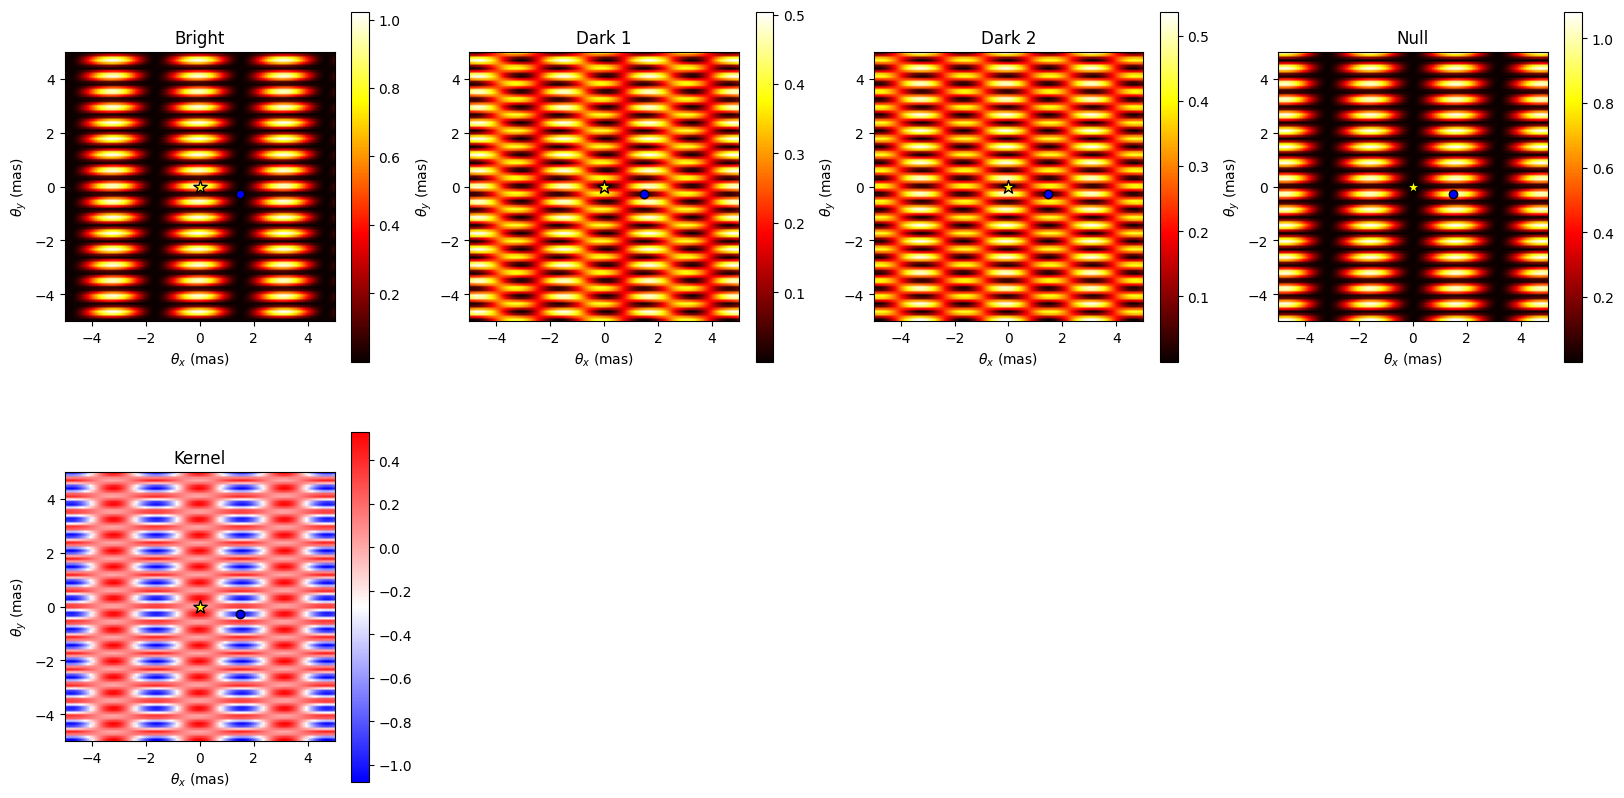


Sun-like @ 10pc Star throughputs:
----------
   Bright: 101.93%,   Dark 1: 0.40%,   Dark 2: 0.18%,   Null: 0.50%
   Kernel: -0.32%
Hypothetical Companion throughputs:
----------
   Bright: 0.34%,   Dark 1: 2.44%,   Dark 2: 1.42%,   Null: 102.08%
   Kernel: -100.66%
Target "Sun-like @ 10pc"
  f: 1e-12 W / (nm m2)
  δ: -65 deg
  Companions:
    Companion "Hypothetical Companion"
      Contrast: 1e-05
      Angular separation: 1.5 mas
      Parallactic angle: -10 deg
---
Camera "Cred3"
  Exposure time: 0.00039 s
  QE: 73% | RON: 37 e- | DC: 7.6e+05 e-/s | Gain: 2 e-/ADU
  Resolution: 11 px | Spot size: 1.0 px | HDR: [] * exposure time



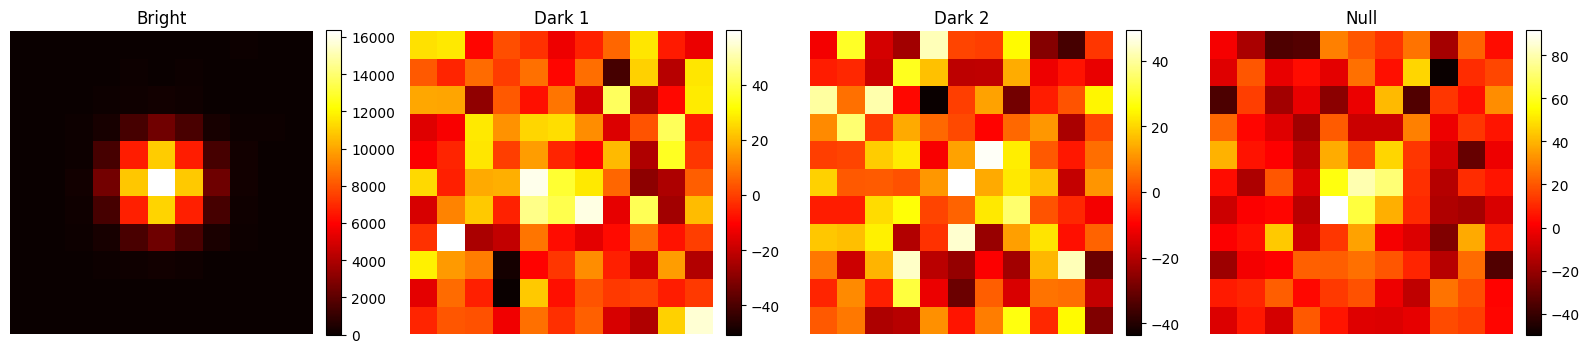

Camera "Cred3"
  Exposure time: 0.0039 s
  QE: 73% | RON: 37 e- | DC: 7.6e+05 e-/s | Gain: 2 e-/ADU
  Resolution: 11 px | Spot size: 1.0 px | HDR: [] * exposure time



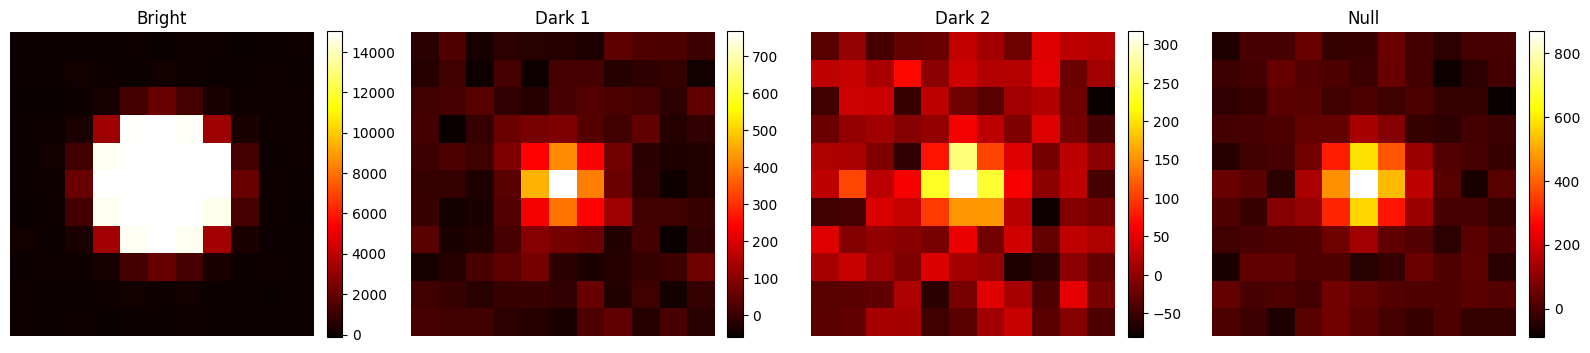

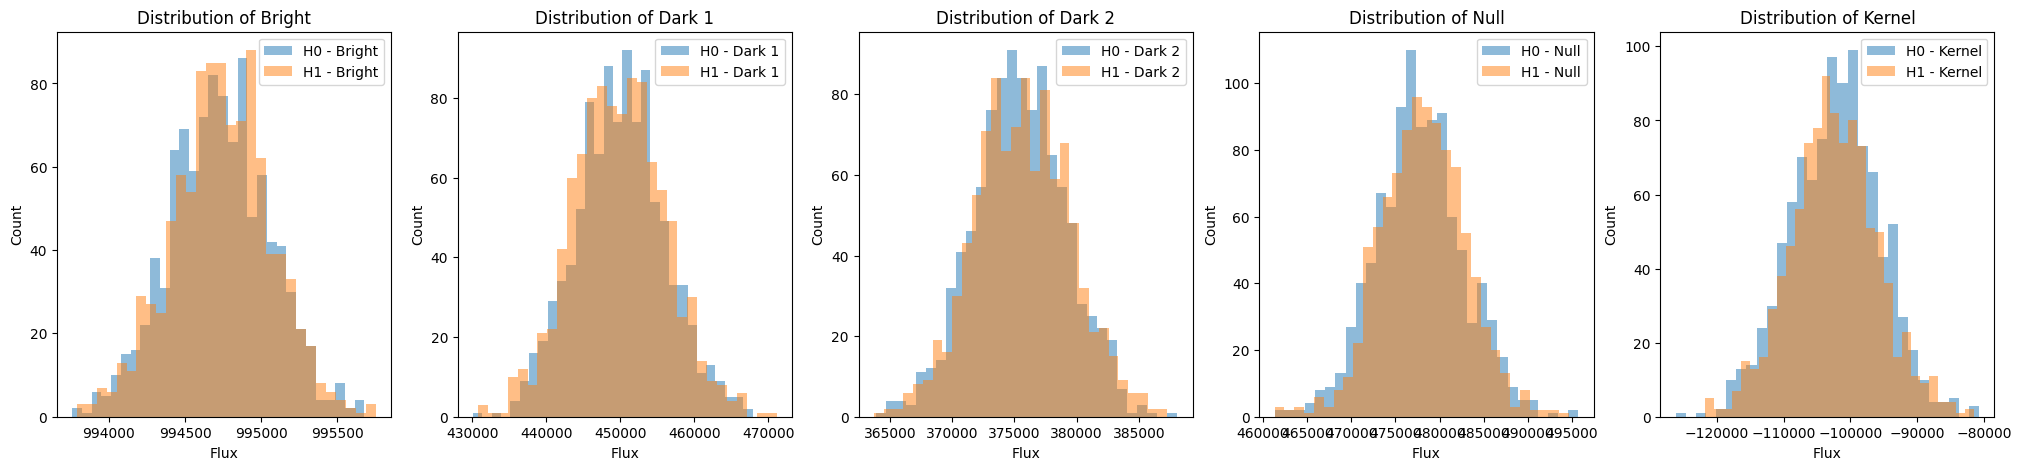

Power of Mean: 4.82%
Power of Median: 6.91%
Power of Kolmogorov-Smirnov: 8.46%
Power of Cramer von Mises: 13.63%
Power of Flattening: 11.09%
Power of Median of Abs: 6.91%


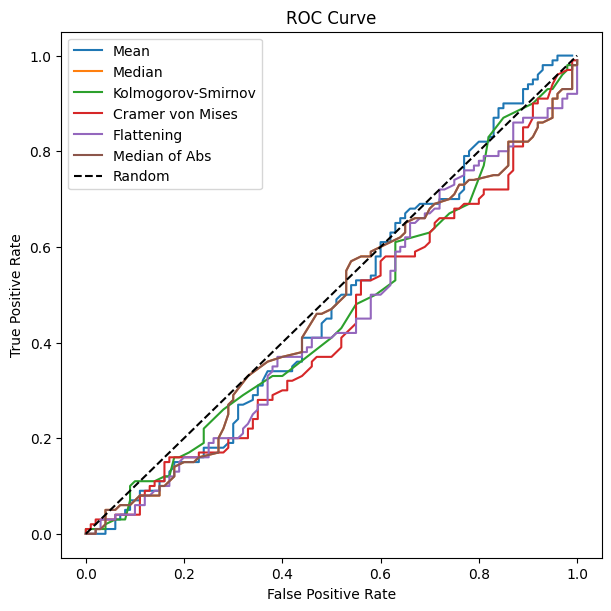

Power of Mean: 8.3%
Power of Median: 24.54%
Power of Kolmogorov-Smirnov: 3.34%
Power of Cramer von Mises: 2.97%
Power of Flattening: 7.89%
Power of Median of Abs: 24.54%


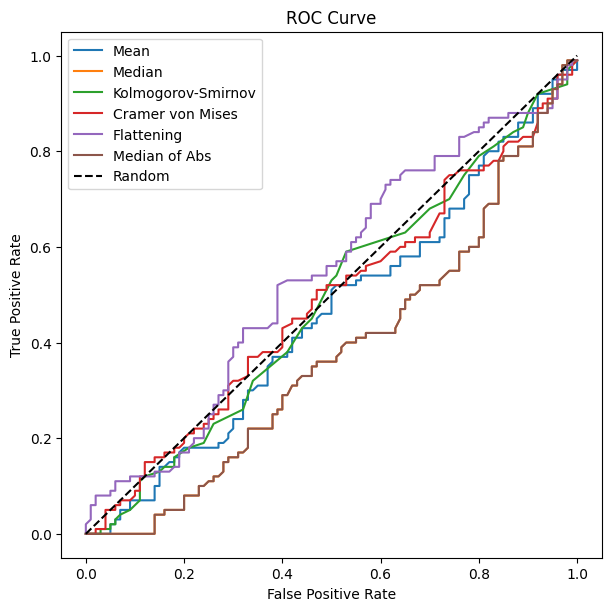

Power of Mean: 3.28%
Power of Median: 0.82%
Power of Kolmogorov-Smirnov: 2.12%
Power of Cramer von Mises: 4.15%
Power of Flattening: 2.65%
Power of Median of Abs: 0.82%


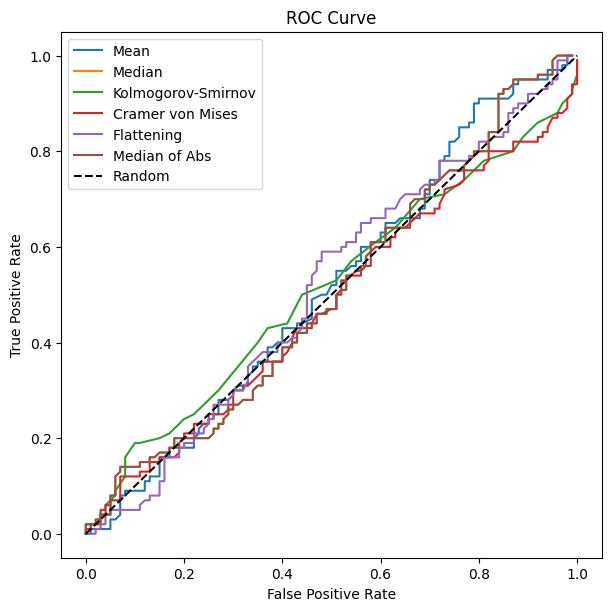

Power of Mean: 99.59%
Power of Median: 98.85%
Power of Kolmogorov-Smirnov: 84.4%
Power of Cramer von Mises: 87.4%
Power of Flattening: 0.75%
Power of Median of Abs: 98.85%


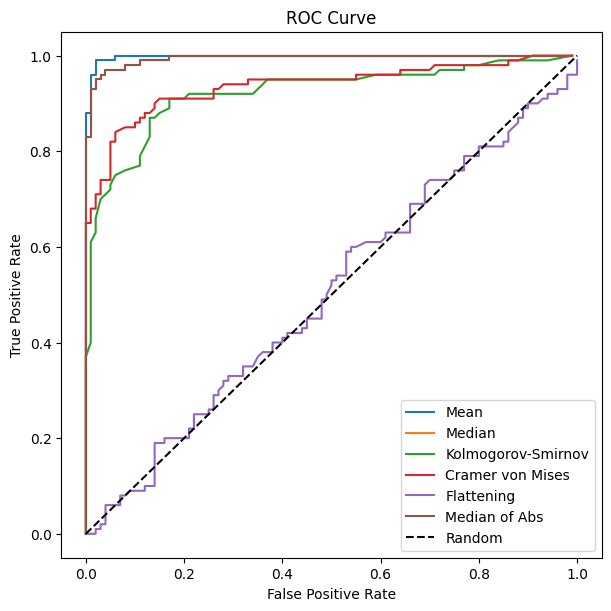

Power of Mean: 82.83%
Power of Median: 73.09%
Power of Kolmogorov-Smirnov: 35.93%
Power of Cramer von Mises: 38.4%
Power of Flattening: 11.89%
Power of Median of Abs: 73.09%


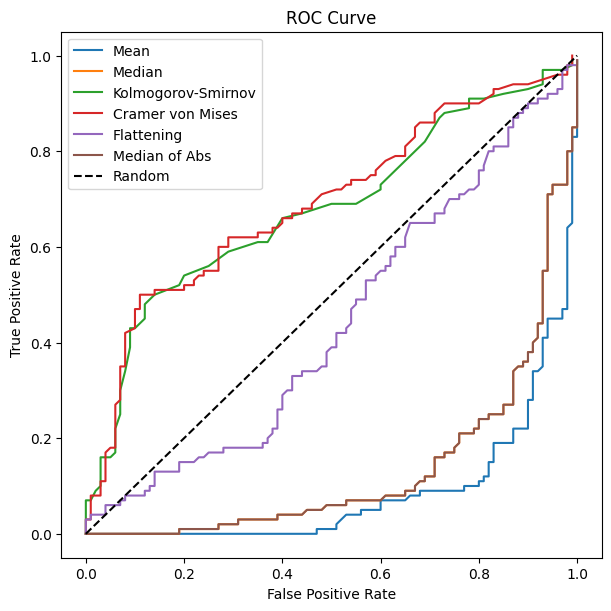

In [5]:
import os

roc_ctx_h1 = phise.examples.contexts.get_LIFE()
roc_ctx_h1.chip = copy(chip)
roc_ctx_h1.camera = copy(camera)
roc_ctx_h1.target.companions[0].c = 1e-5
roc_ctx_h1.target.companions[0].ρ = 1.5 * u.mas
roc_ctx_h1.target.companions[0].θ = -10 * u.deg
roc_ctx_h1.plot_transmission_maps(N=100)
print(roc_ctx_h1.target)
print("---")
roc_ctx_h1.camera.e = roc_ctx_h1.get_reference_exposure_time(target_adu_fraction=1)
print(roc_ctx_h1.camera)  
roc_ctx_h1.observe(mode="demo"); plt.show()
roc_ctx_h1.camera.e = roc_ctx_h1.get_reference_exposure_time(target_adu_fraction=10)
print(roc_ctx_h1.camera)  
roc_ctx_h1.observe(mode="demo"); plt.show()

roc_ctx_h1.interferometer.Δλ = 100 * u.um

roc_ctx_h0 = copy(roc_ctx_h1)
roc_ctx_h0.target.companions = []

roc_ctx_h1.name = "H1"
roc_ctx_h0.name = "H0"
roc_ctx_h1.plot_distributions(samples=1000, ctx_h0=roc_ctx_h0); plt.show()

force_generate = False
if os.path.exists("roc_data_life.npz") and not force_generate:
    loaded = np.load("roc_data_life.npz")
    T0 = loaded["T0"]
    T1 = loaded["T1"]
else:
    T0, T1 = phise.roc.generate_data(roc_ctx_h1, roc_ctx_h0, nmc=100, size=1000, progress_callback=lambda p: print(f"Progress: {p:.1%}", end='\r'), randomize_position=False)
    np.savez("roc_data_life.npz", T0=T0, T1=T1)

for i in range(5):
    phise.roc.plot_roc_curves(T0[i], T1[i])